# Cancer as a Metabolic-Adaptive State Space
## Full proof-of-concept simulation and analysis script

# IMPORTANT
The numeric values below are SIMULATED. They are benchmarked to
relative biological patterns reported in peer-reviewed literature,
not pooled clinical reference ranges.

# Literature anchors for simulation logic:
# - Finley & Vasan, Cell (2023)
# - Gupta et al., Cell Stem Cell (2019)
# - Sobanski et al., Front Cell Dev Biol (2021)
# - Jin et al., Exp Mol Med (2023)
#
# Conceptual mapping:
# - Glycolytic / lactate-high cancer states
# - OXPHOS-competent states
# - Glutamine-addicted states
# - Hybrid plastic states
# - Repair-deficient stressed states
# - Drug-tolerant adaptive states

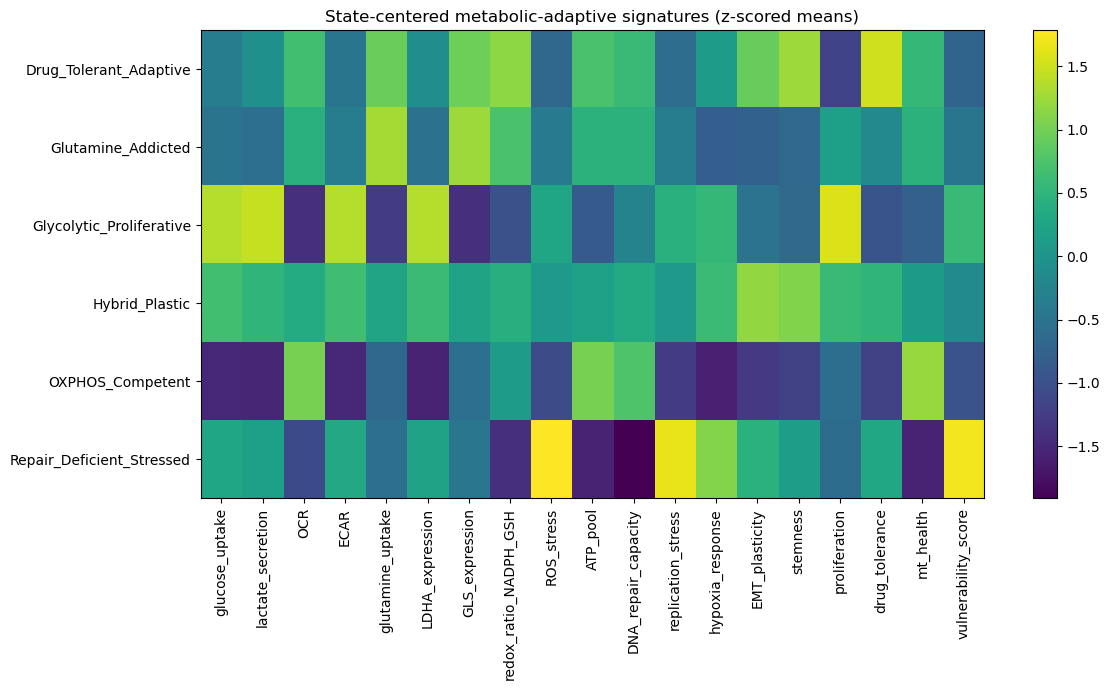

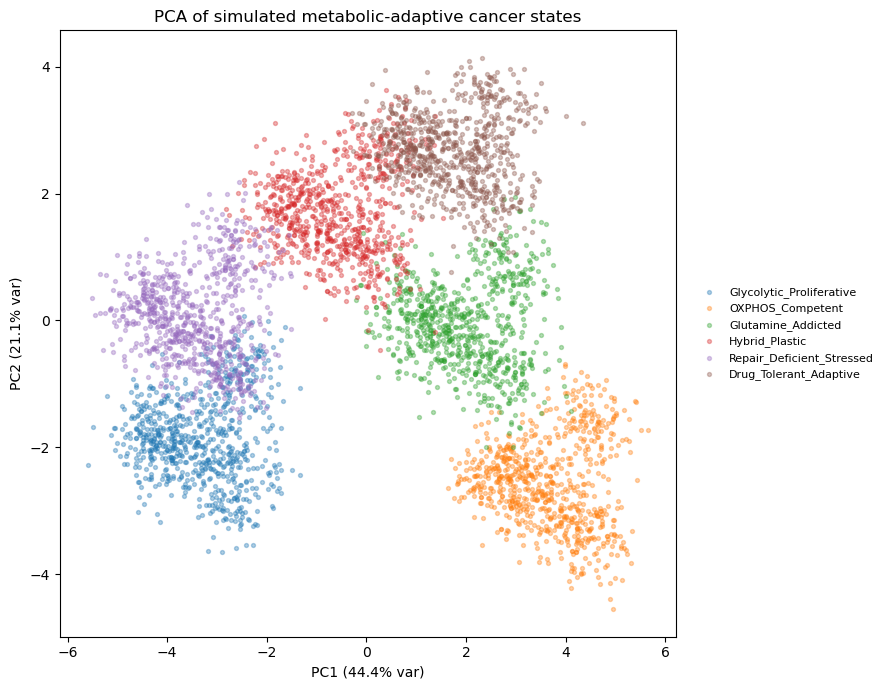

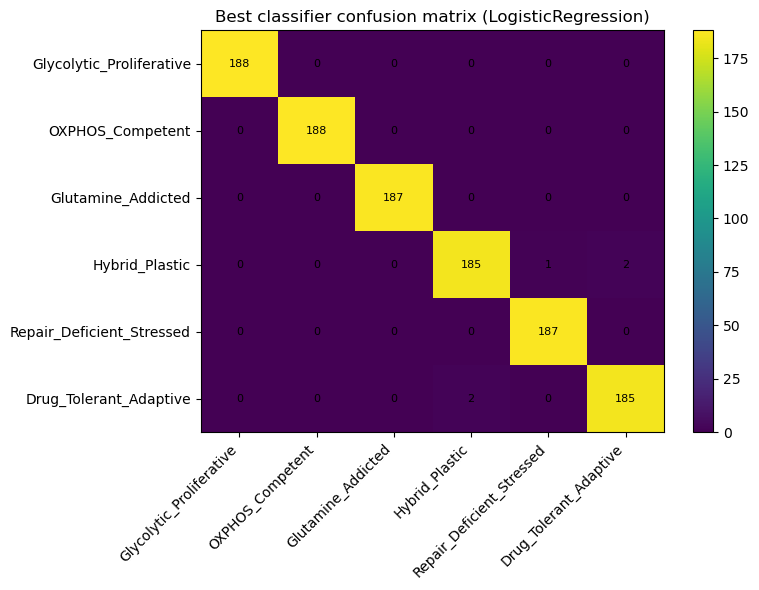

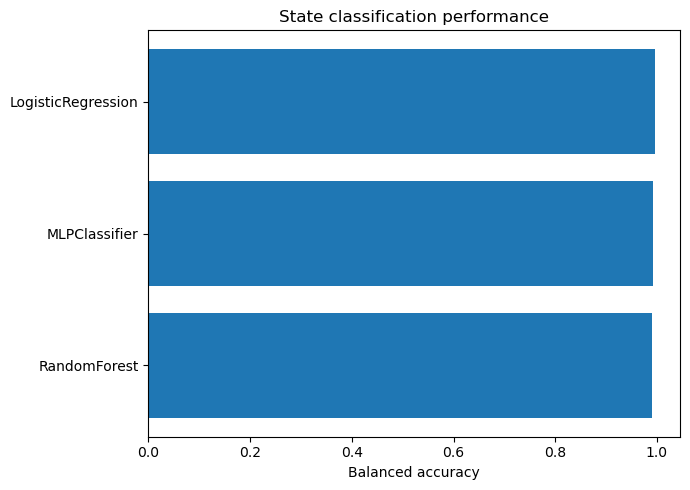

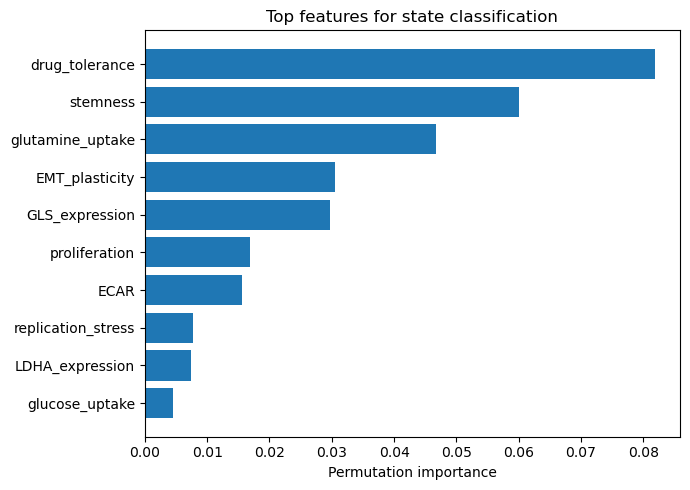

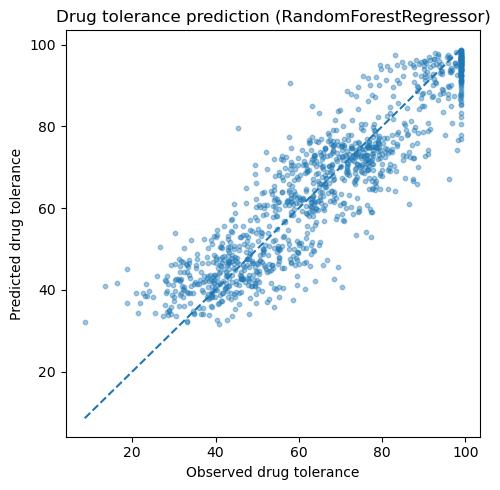

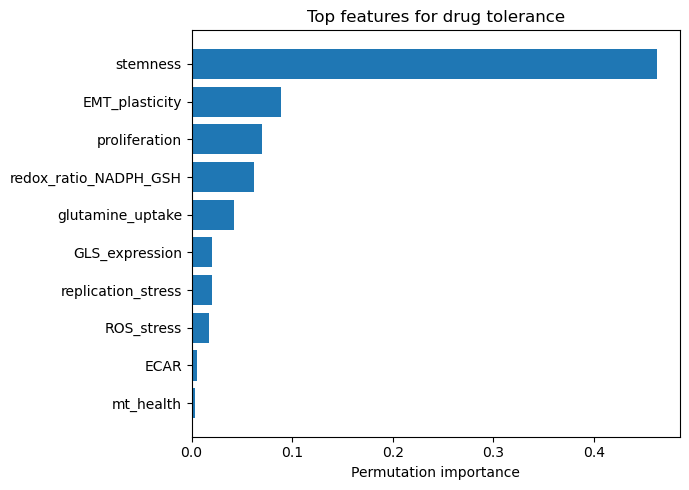

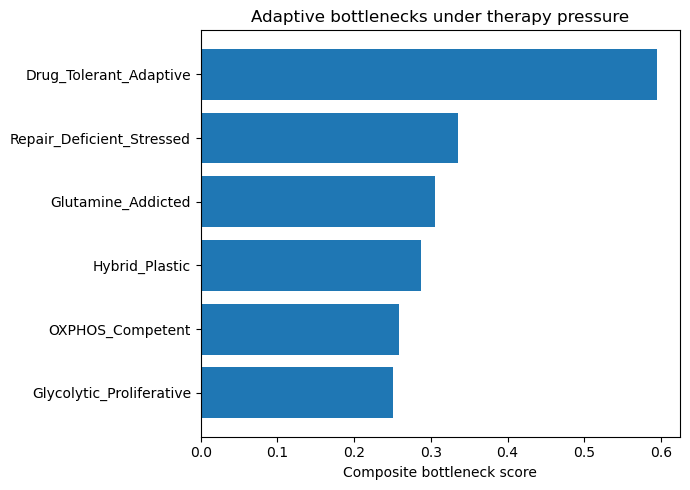

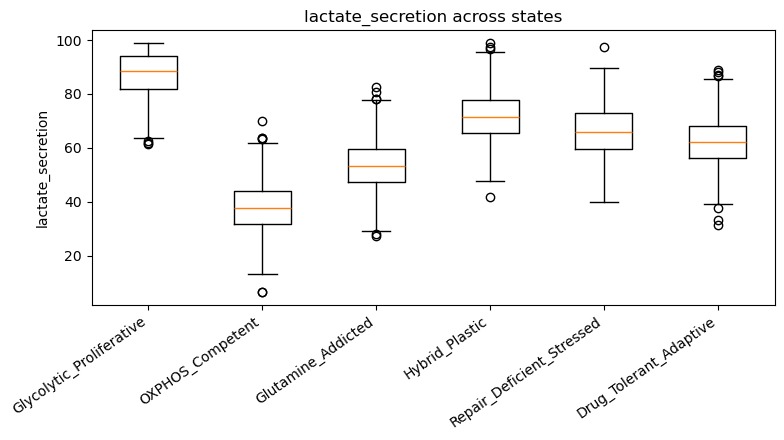

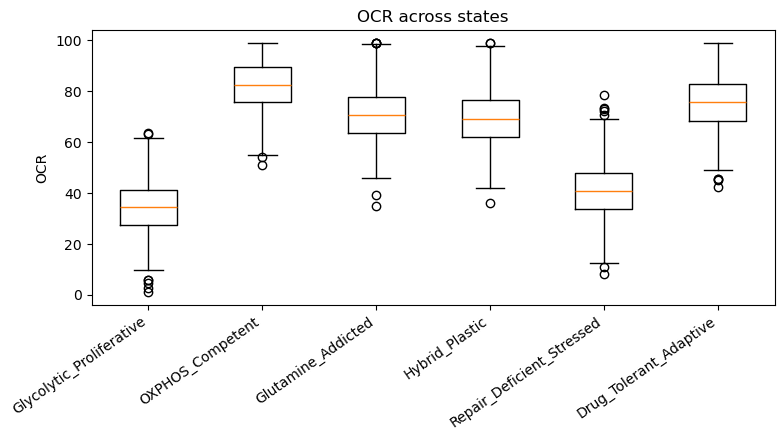

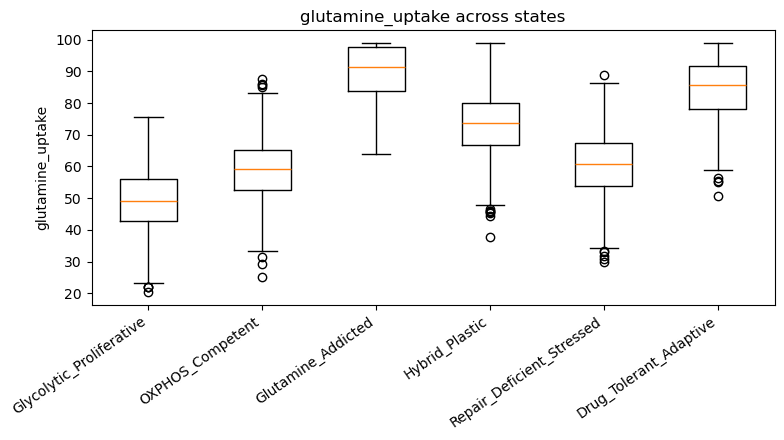

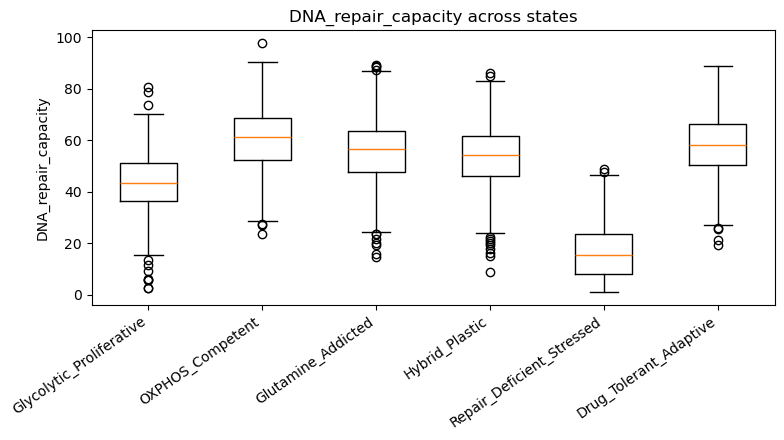

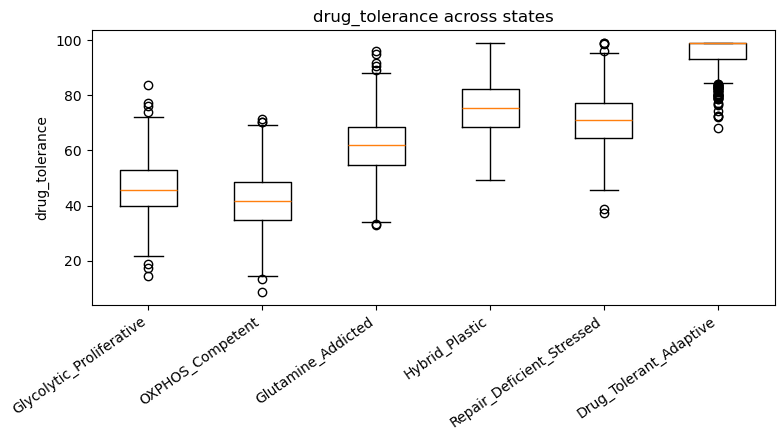

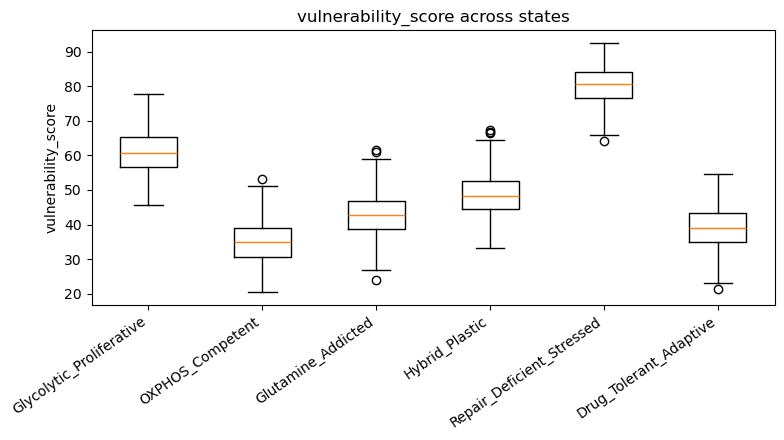

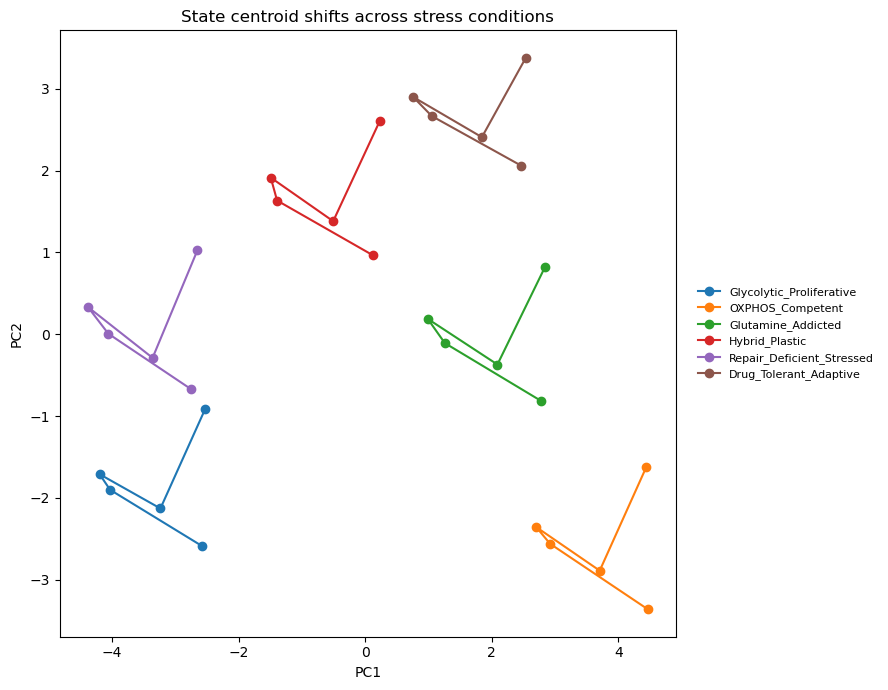

Artifacts written to: cancer_state_space_outputs
   best_classifier  best_balanced_accuracy        best_regressor  best_regressor_R2  clustering_ARI  clustering_NMI
LogisticRegression                   0.996 RandomForestRegressor              0.825           0.967           0.965

Top classifier features:
           feature  importance_mean  importance_std
    drug_tolerance            0.082           0.004
          stemness            0.060           0.004
  glutamine_uptake            0.047           0.005
    EMT_plasticity            0.030           0.003
    GLS_expression            0.030           0.003
     proliferation            0.017           0.002
              ECAR            0.016           0.003
replication_stress            0.008           0.001

Top therapy-pressure bottlenecks:
                    state  therapy_outgoing_entropy  therapy_self_retention  therapy_to_drug_tolerant  bottleneck_score
   Drug_Tolerant_Adaptive                     1.318                   

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    mean_absolute_error,
    r2_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance



OUTDIR = Path("cancer_state_space_outputs")
OUTDIR.mkdir(exist_ok=True)
np.random.seed(42)

STATES = [
    "Glycolytic_Proliferative",
    "OXPHOS_Competent",
    "Glutamine_Addicted",
    "Hybrid_Plastic",
    "Repair_Deficient_Stressed",
    "Drug_Tolerant_Adaptive",
]

FEATURES = [
    "glucose_uptake",
    "lactate_secretion",
    "OCR",
    "ECAR",
    "glutamine_uptake",
    "LDHA_expression",
    "GLS_expression",
    "redox_ratio_NADPH_GSH",
    "ROS_stress",
    "ATP_pool",
    "DNA_repair_capacity",
    "replication_stress",
    "hypoxia_response",
    "EMT_plasticity",
    "stemness",
    "proliferation",
    "drug_tolerance",
    "mt_health",
]

STATE_MEANS = {
    "Glycolytic_Proliferative":      [82, 86, 38, 84, 48, 79, 42, 44, 58, 52, 50, 62, 61, 42, 35, 88, 36, 46],
    "OXPHOS_Competent":              [42, 36, 86, 41, 58, 34, 56, 66, 35, 82, 67, 32, 28, 24, 22, 58, 32, 84],
    "Glutamine_Addicted":            [56, 52, 74, 58, 90, 50, 87, 78, 46, 73, 62, 48, 40, 36, 34, 68, 52, 70],
    "Hybrid_Plastic":                [72, 70, 72, 73, 72, 68, 69, 71, 54, 69, 60, 56, 62, 81, 76, 74, 66, 63],
    "Repair_Deficient_Stressed":     [66, 64, 44, 68, 60, 61, 58, 36, 84, 41, 22, 88, 70, 63, 54, 57, 61, 32],
    "Drug_Tolerant_Adaptive":        [58, 60, 79, 56, 84, 57, 82, 86, 42, 77, 64, 44, 55, 74, 80, 49, 91, 72],
}
STATE_STD = np.array([8, 8, 9, 8, 8, 9, 9, 8, 8, 9, 10, 8, 9, 9, 9, 10, 8, 9])

STRESSORS = ["Baseline", "Nutrient_Stress", "Hypoxia_like", "Genotoxic", "Therapy_Pressure"]
STRESS_EFFECTS = {
    "Baseline":              [0] * len(FEATURES),
    "Nutrient_Stress":       [-8, -4, -5, -2, -10, 0, 4, -8, 10, -10, -2, 8, 6, 10, 8, -12, 8, -8],
    "Hypoxia_like":          [8, 10, -10, 10, 4, 8, 0, -6, 10, -8, -4, 8, 22, 10, 6, -6, 10, -10],
    "Genotoxic":             [2, 4, -6, 4, 2, 3, 2, -6, 16, -8, -18, 22, 4, 8, 6, -8, 10, -10],
    "Therapy_Pressure":      [-4, 0, 6, -2, 8, 2, 8, 12, 4, 0, -8, 10, 6, 12, 14, -18, 20, -2],
}

TRANSITION_PROB = {
    "Nutrient_Stress": {
        "Glycolytic_Proliferative": {"Hybrid_Plastic": 0.35, "Glutamine_Addicted": 0.30, "Drug_Tolerant_Adaptive": 0.20, "Glycolytic_Proliferative": 0.15},
        "OXPHOS_Competent": {"Hybrid_Plastic": 0.30, "Drug_Tolerant_Adaptive": 0.25, "OXPHOS_Competent": 0.30, "Glutamine_Addicted": 0.15},
        "Glutamine_Addicted": {"Drug_Tolerant_Adaptive": 0.35, "Glutamine_Addicted": 0.35, "Hybrid_Plastic": 0.20, "Repair_Deficient_Stressed": 0.10},
        "Hybrid_Plastic": {"Drug_Tolerant_Adaptive": 0.35, "Hybrid_Plastic": 0.30, "Glutamine_Addicted": 0.20, "Repair_Deficient_Stressed": 0.15},
        "Repair_Deficient_Stressed": {"Repair_Deficient_Stressed": 0.45, "Hybrid_Plastic": 0.25, "Drug_Tolerant_Adaptive": 0.20, "Glutamine_Addicted": 0.10},
        "Drug_Tolerant_Adaptive": {"Drug_Tolerant_Adaptive": 0.55, "Hybrid_Plastic": 0.20, "Glutamine_Addicted": 0.15, "Repair_Deficient_Stressed": 0.10},
    },
    "Hypoxia_like": {
        "Glycolytic_Proliferative": {"Glycolytic_Proliferative": 0.45, "Hybrid_Plastic": 0.35, "Drug_Tolerant_Adaptive": 0.20},
        "OXPHOS_Competent": {"Hybrid_Plastic": 0.35, "Drug_Tolerant_Adaptive": 0.25, "OXPHOS_Competent": 0.20, "Glutamine_Addicted": 0.20},
        "Glutamine_Addicted": {"Hybrid_Plastic": 0.30, "Drug_Tolerant_Adaptive": 0.30, "Glutamine_Addicted": 0.25, "Repair_Deficient_Stressed": 0.15},
        "Hybrid_Plastic": {"Hybrid_Plastic": 0.40, "Drug_Tolerant_Adaptive": 0.30, "Glycolytic_Proliferative": 0.15, "Repair_Deficient_Stressed": 0.15},
        "Repair_Deficient_Stressed": {"Repair_Deficient_Stressed": 0.40, "Hybrid_Plastic": 0.30, "Drug_Tolerant_Adaptive": 0.20, "Glycolytic_Proliferative": 0.10},
        "Drug_Tolerant_Adaptive": {"Drug_Tolerant_Adaptive": 0.55, "Hybrid_Plastic": 0.25, "Glutamine_Addicted": 0.10, "Repair_Deficient_Stressed": 0.10},
    },
    "Genotoxic": {
        "Glycolytic_Proliferative": {"Repair_Deficient_Stressed": 0.30, "Hybrid_Plastic": 0.25, "Drug_Tolerant_Adaptive": 0.20, "Glycolytic_Proliferative": 0.25},
        "OXPHOS_Competent": {"Repair_Deficient_Stressed": 0.25, "Hybrid_Plastic": 0.25, "Drug_Tolerant_Adaptive": 0.20, "OXPHOS_Competent": 0.30},
        "Glutamine_Addicted": {"Repair_Deficient_Stressed": 0.25, "Drug_Tolerant_Adaptive": 0.30, "Glutamine_Addicted": 0.25, "Hybrid_Plastic": 0.20},
        "Hybrid_Plastic": {"Drug_Tolerant_Adaptive": 0.30, "Repair_Deficient_Stressed": 0.25, "Hybrid_Plastic": 0.25, "Glutamine_Addicted": 0.20},
        "Repair_Deficient_Stressed": {"Repair_Deficient_Stressed": 0.55, "Drug_Tolerant_Adaptive": 0.20, "Hybrid_Plastic": 0.15, "Glutamine_Addicted": 0.10},
        "Drug_Tolerant_Adaptive": {"Drug_Tolerant_Adaptive": 0.50, "Repair_Deficient_Stressed": 0.20, "Hybrid_Plastic": 0.20, "Glutamine_Addicted": 0.10},
    },
    "Therapy_Pressure": {
        "Glycolytic_Proliferative": {"Drug_Tolerant_Adaptive": 0.32, "Hybrid_Plastic": 0.28, "Repair_Deficient_Stressed": 0.15, "Glycolytic_Proliferative": 0.25},
        "OXPHOS_Competent": {"Drug_Tolerant_Adaptive": 0.30, "Hybrid_Plastic": 0.25, "OXPHOS_Competent": 0.25, "Glutamine_Addicted": 0.20},
        "Glutamine_Addicted": {"Drug_Tolerant_Adaptive": 0.38, "Glutamine_Addicted": 0.26, "Hybrid_Plastic": 0.20, "Repair_Deficient_Stressed": 0.16},
        "Hybrid_Plastic": {"Drug_Tolerant_Adaptive": 0.40, "Hybrid_Plastic": 0.25, "Repair_Deficient_Stressed": 0.20, "Glutamine_Addicted": 0.15},
        "Repair_Deficient_Stressed": {"Drug_Tolerant_Adaptive": 0.28, "Repair_Deficient_Stressed": 0.42, "Hybrid_Plastic": 0.20, "Glutamine_Addicted": 0.10},
        "Drug_Tolerant_Adaptive": {"Drug_Tolerant_Adaptive": 0.70, "Hybrid_Plastic": 0.15, "Glutamine_Addicted": 0.10, "Repair_Deficient_Stressed": 0.05},
    },
}


def simulate_rows(state: str, n: int, stressor: str = "Baseline") -> pd.DataFrame:
    means = np.array(STATE_MEANS[state], dtype=float) + np.array(STRESS_EFFECTS[stressor], dtype=float)
    X = np.random.normal(loc=means, scale=STATE_STD, size=(n, len(FEATURES)))
    X = np.clip(X, 1, 99)
    df = pd.DataFrame(X, columns=FEATURES)
    df["state"] = state
    df["stressor"] = stressor
    df["vulnerability_score"] = (
        0.22 * (100 - df["DNA_repair_capacity"]) +
        0.18 * df["ROS_stress"] +
        0.18 * df["replication_stress"] +
        0.14 * (100 - df["ATP_pool"]) +
        0.12 * (100 - df["redox_ratio_NADPH_GSH"]) +
        0.16 * (100 - df["mt_health"])
    ).clip(0, 100)
    return df


def weighted_choice(prob_map: dict) -> str:
    names = list(prob_map.keys())
    probs = np.array(list(prob_map.values()), dtype=float)
    probs = probs / probs.sum()
    return np.random.choice(names, p=probs)


def simulate_lineages(n_lineages: int, stressor: str) -> pd.DataFrame:
    base_states = np.random.choice(STATES, size=n_lineages, p=[0.19, 0.16, 0.16, 0.18, 0.13, 0.18])
    rows = []
    for i, start_state in enumerate(base_states):
        current = start_state
        lineage_id = f"LG_{stressor[:3]}_{i:05d}"
        for t in [0, 1, 2]:
            row = simulate_rows(current, 1, stressor if t > 0 else "Baseline").iloc[0].to_dict()
            row["lineage_id"] = lineage_id
            row["timepoint"] = t
            rows.append(row)
            if t < 2:
                current = weighted_choice(TRANSITION_PROB[stressor][current])
    return pd.DataFrame(rows)


def save_barh(df, value_col, label_col, title, xlabel, filename):
    plt.figure(figsize=(7, 5))
    ordered = df.sort_values(value_col)
    plt.barh(ordered[label_col], ordered[value_col])
    plt.xlabel(xlabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()
    plt.savefig(OUTDIR / filename, dpi=160)
    plt.close()


def save_boxplot(df, feature, filename):
    plt.figure(figsize=(8, 4.5))
    data = [df.loc[df["state"] == s, feature].values for s in STATES]
    plt.boxplot(data, tick_labels=STATES)
    plt.xticks(rotation=35, ha="right")
    plt.ylabel(feature)
    plt.title(f"{feature} across states")
    plt.tight_layout()
    plt.show()
    plt.savefig(OUTDIR / filename, dpi=160)
    plt.close()


def main():
    cross = pd.concat([simulate_rows(s, 150, st) for st in STRESSORS for s in STATES], ignore_index=True)
    longitudinal = pd.concat([simulate_lineages(240, st) for st in ["Nutrient_Stress", "Hypoxia_like", "Genotoxic", "Therapy_Pressure"]], ignore_index=True)

    cross.to_csv(OUTDIR / "simulated_cancer_state_space_cross_sectional.csv", index=False)
    longitudinal.to_csv(OUTDIR / "simulated_cancer_state_space_longitudinal.csv", index=False)

    state_summary = cross.groupby("state")[FEATURES + ["vulnerability_score"]].mean().round(2)
    stress_summary = cross.groupby("stressor")[FEATURES + ["vulnerability_score"]].mean().round(2)
    state_summary.to_csv(OUTDIR / "state_summary_means.csv")
    stress_summary.to_csv(OUTDIR / "stressor_summary_means.csv")

    # Supervised ML
    X = cross[FEATURES]
    y = cross["state"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)

    classifiers = {
        "LogisticRegression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2500))
        ]),
        "RandomForest": Pipeline([
            ("clf", RandomForestClassifier(n_estimators=250, random_state=42, class_weight="balanced", min_samples_leaf=3))
        ]),
        "MLPClassifier": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", MLPClassifier(hidden_layer_sizes=(40, 20), max_iter=300, random_state=42))
        ]),
    }

    clf_rows = []
    fit_clf = {}
    for name, model in classifiers.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        clf_rows.append({
            "model": name,
            "accuracy": accuracy_score(y_test, pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        })
        fit_clf[name] = model
    clf_results = pd.DataFrame(clf_rows).sort_values("balanced_accuracy", ascending=False)
    clf_results.to_csv(OUTDIR / "classification_results.csv", index=False)

    best_clf_name = clf_results.iloc[0]["model"]
    best_clf = fit_clf[best_clf_name]
    best_pred = best_clf.predict(X_test)
    cm = pd.DataFrame(confusion_matrix(y_test, best_pred, labels=STATES), index=STATES, columns=STATES)
    cm.to_csv(OUTDIR / "best_classifier_confusion_matrix.csv")

    # Regression
    reg_features = [f for f in FEATURES if f != "drug_tolerance"]
    Xr = cross[reg_features]
    yr = cross["drug_tolerance"]
    Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.25, random_state=42)

    regressors = {
        "Ridge": Pipeline([("scaler", StandardScaler()), ("reg", Ridge(alpha=1.0))]),
        "RandomForestRegressor": Pipeline([("reg", RandomForestRegressor(n_estimators=250, random_state=42, min_samples_leaf=3))]),
        "GradientBoostingRegressor": Pipeline([("reg", GradientBoostingRegressor(random_state=42))]),
    }

    reg_rows = []
    fit_reg = {}
    for name, model in regressors.items():
        model.fit(Xr_train, yr_train)
        pred = model.predict(Xr_test)
        reg_rows.append({
            "model": name,
            "R2": r2_score(yr_test, pred),
            "MAE": mean_absolute_error(yr_test, pred),
        })
        fit_reg[name] = model
    reg_results = pd.DataFrame(reg_rows).sort_values("R2", ascending=False)
    reg_results.to_csv(OUTDIR / "regression_results.csv", index=False)

    best_reg_name = reg_results.iloc[0]["model"]
    best_reg = fit_reg[best_reg_name]
    best_reg_pred = best_reg.predict(Xr_test)

    # Unsupervised
    X_scaled = StandardScaler().fit_transform(X)
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    sample_idx = np.random.choice(len(cross), size=min(1000, len(cross)), replace=False)
    tsne = TSNE(n_components=2, perplexity=25, learning_rate="auto", init="pca", random_state=42)
    X_tsne = tsne.fit_transform(X_scaled[sample_idx])
    tsne_labels = y.iloc[sample_idx].reset_index(drop=True)

    kmeans = KMeans(n_clusters=len(STATES), n_init=20, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    ari = adjusted_rand_score(y, clusters)
    nmi = normalized_mutual_info_score(y, clusters)

    clf_perm = permutation_importance(best_clf, X_test, y_test, n_repeats=4, random_state=42)
    clf_imp = pd.DataFrame({
        "feature": FEATURES,
        "importance_mean": clf_perm.importances_mean,
        "importance_std": clf_perm.importances_std,
    }).sort_values("importance_mean", ascending=False)
    clf_imp.to_csv(OUTDIR / "classifier_feature_importance.csv", index=False)

    reg_perm = permutation_importance(best_reg, Xr_test, yr_test, n_repeats=4, random_state=42)
    reg_imp = pd.DataFrame({
        "feature": reg_features,
        "importance_mean": reg_perm.importances_mean,
        "importance_std": reg_perm.importances_std,
    }).sort_values("importance_mean", ascending=False)
    reg_imp.to_csv(OUTDIR / "regressor_feature_importance.csv", index=False)

    # Transition analysis
    def transition_matrix(df, prefix):
        sub = df[df["lineage_id"].str.contains(prefix[:3])].sort_values(["lineage_id", "timepoint"])
        transitions = []
        for _, g in sub.groupby("lineage_id"):
            seq = g["state"].tolist()
            for a, b in zip(seq[:-1], seq[1:]):
                transitions.append((a, b))
        mat = pd.crosstab(
            pd.Series([a for a, b in transitions], name="from"),
            pd.Series([b for a, b in transitions], name="to"),
            normalize="index"
        )
        return mat.reindex(index=STATES, columns=STATES).fillna(0)

    tm_therapy = transition_matrix(longitudinal, "Therapy_Pressure")
    tm_nutrient = transition_matrix(longitudinal, "Nutrient_Stress")
    tm_hypoxia = transition_matrix(longitudinal, "Hypoxia_like")
    tm_genotoxic = transition_matrix(longitudinal, "Genotoxic")
    tm_therapy.to_csv(OUTDIR / "transition_matrix_therapy.csv")
    tm_nutrient.to_csv(OUTDIR / "transition_matrix_nutrient.csv")
    tm_hypoxia.to_csv(OUTDIR / "transition_matrix_hypoxia.csv")
    tm_genotoxic.to_csv(OUTDIR / "transition_matrix_genotoxic.csv")

    def entropy(vals):
        vals = np.array(vals, dtype=float)
        vals = vals[vals > 0]
        return float(-(vals * np.log2(vals)).sum())

    bottleneck_df = pd.DataFrame({
        "state": STATES,
        "therapy_outgoing_entropy": [entropy(tm_therapy.loc[s].values) for s in STATES],
        "therapy_self_retention": [tm_therapy.loc[s, s] for s in STATES],
        "therapy_to_drug_tolerant": [tm_therapy.loc[s, "Drug_Tolerant_Adaptive"] for s in STATES],
    })
    bottleneck_df["bottleneck_score"] = (
        0.5 * (1 - bottleneck_df["therapy_outgoing_entropy"] / np.log2(len(STATES))) +
        0.3 * bottleneck_df["therapy_self_retention"] +
        0.2 * bottleneck_df["therapy_to_drug_tolerant"]
    )
    bottleneck_df.to_csv(OUTDIR / "transition_bottleneck_scores.csv", index=False)

    # Figures
    plt.figure(figsize=(12, 7))
    heat = (state_summary - state_summary.mean()) / state_summary.std()
    plt.imshow(heat.values, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(heat.columns)), heat.columns, rotation=90)
    plt.yticks(range(len(heat.index)), heat.index)
    plt.title("State-centered metabolic-adaptive signatures (z-scored means)")
    plt.tight_layout()
    plt.show()
    plt.savefig(OUTDIR / "figure_01_state_heatmap.png", dpi=160)
    plt.close()

    pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
    pca_df["state"] = y.values
    pca_df["stressor"] = cross["stressor"].values
    plt.figure(figsize=(9, 7))
    for s in STATES:
        sub = pca_df[pca_df["state"] == s]
        plt.scatter(sub["PC1"], sub["PC2"], s=8, alpha=0.35, label=s)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
    plt.title("PCA of simulated metabolic-adaptive cancer states")
    plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()
    plt.savefig(OUTDIR / "figure_02_pca.png", dpi=160)
    plt.close()

    tsne_df = pd.DataFrame(X_tsne, columns=["tSNE1", "tSNE2"])
    tsne_df["state"] = tsne_labels.values
    plt.figure(figsize=(9, 7))
    for s in STATES:
        sub = tsne_df[tsne_df["state"] == s]
        plt.scatter(sub["tSNE1"], sub["tSNE2"], s=10, alpha=0.35, label=s)
    plt.xlabel("t-SNE1")
    plt.ylabel("t-SNE2")
    plt.title("Nonlinear embedding of simulated cancer states")
    plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=8)
    plt.tight_layout()
    plt.savefig(OUTDIR / "figure_03_tsne.png", dpi=160)
    plt.close()

    plt.figure(figsize=(8, 6))
    plt.imshow(cm.values, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(STATES)), STATES, rotation=45, ha="right")
    plt.yticks(range(len(STATES)), STATES)
    for i in range(len(STATES)):
        for j in range(len(STATES)):
            plt.text(j, i, int(cm.values[i, j]), ha="center", va="center", fontsize=8)
    plt.title(f"Best classifier confusion matrix ({best_clf_name})")
    plt.tight_layout()
    plt.show()
    plt.savefig(OUTDIR / "figure_04_confusion_matrix.png", dpi=160)
    plt.close()

    save_barh(clf_results, "balanced_accuracy", "model", "State classification performance", "Balanced accuracy", "figure_05_classifier_performance.png")
    save_barh(clf_imp.head(10), "importance_mean", "feature", "Top features for state classification", "Permutation importance", "figure_06_classifier_importance.png")

    plt.figure(figsize=(5, 5))
    plt.scatter(yr_test, best_reg_pred, s=10, alpha=0.4)
    mn = min(float(yr_test.min()), float(best_reg_pred.min()))
    mx = max(float(yr_test.max()), float(best_reg_pred.max()))
    plt.plot([mn, mx], [mn, mx], linestyle="--")
    plt.xlabel("Observed drug tolerance")
    plt.ylabel("Predicted drug tolerance")
    plt.title(f"Drug tolerance prediction ({best_reg_name})")
    plt.tight_layout()
    plt.show()
    plt.savefig(OUTDIR / "figure_07_regression_pred_vs_obs.png", dpi=160)
    plt.close()

    save_barh(reg_imp.head(10), "importance_mean", "feature", "Top features for drug tolerance", "Permutation importance", "figure_08_regressor_importance.png")

    plt.figure(figsize=(8, 6))
    plt.imshow(tm_therapy.values, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(STATES)), STATES, rotation=45, ha="right")
    plt.yticks(range(len(STATES)), STATES)
    for i in range(len(STATES)):
        for j in range(len(STATES)):
            plt.text(j, i, f"{tm_therapy.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
    plt.title("Therapy-pressure transition matrix")
    plt.tight_layout()
    plt.savefig(OUTDIR / "figure_09_transition_matrix_therapy.png", dpi=160)
    plt.close()

    save_barh(bottleneck_df, "bottleneck_score", "state", "Adaptive bottlenecks under therapy pressure", "Composite bottleneck score", "figure_10_bottleneck_scores.png")

    for feat in ["lactate_secretion", "OCR", "glutamine_uptake", "DNA_repair_capacity", "drug_tolerance", "vulnerability_score"]:
        save_boxplot(cross, feat, f"figure_boxplot_{feat}.png")

    centroids = pca_df.groupby(["state", "stressor"])[["PC1", "PC2"]].mean().reset_index()
    plt.figure(figsize=(9, 7))
    for s in STATES:
        sub = centroids[centroids["state"] == s]
        plt.plot(sub["PC1"], sub["PC2"], marker="o", label=s)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("State centroid shifts across stress conditions")
    plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()
    plt.savefig(OUTDIR / "figure_12_centroid_shifts.png", dpi=160)
    plt.close()

    # Text outputs
    summary = pd.DataFrame({
        "best_classifier": [best_clf_name],
        "best_balanced_accuracy": [round(float(clf_results.iloc[0]["balanced_accuracy"]), 3)],
        "best_regressor": [best_reg_name],
        "best_regressor_R2": [round(float(reg_results.iloc[0]["R2"]), 3)],
        "clustering_ARI": [round(float(ari), 3)],
        "clustering_NMI": [round(float(nmi), 3)],
    })
    summary.to_csv(OUTDIR / "summary_results.csv", index=False)

    readme = f'''# Cancer as a Metabolic-Adaptive State Space — Simulated Proof-of-Concept

## What was done
A literature-anchored simulated dataset was generated to reflect core concepts in cancer metabolic plasticity, DNA repair–metabolism coupling, glutamine dependence, lactate-rich glycolytic states, hybrid plastic states, and drug-tolerant adaptation.

## Important caveat
These values are simulated and should not be interpreted as exact clinical biomarker reference ranges. They are benchmarked to relative patterns described in peer-reviewed literature.

## Key numerical results
- Best classifier: {best_clf_name}
- Balanced accuracy: {clf_results.iloc[0]['balanced_accuracy']:.3f}
- Best regressor: {best_reg_name}
- R² for drug tolerance: {reg_results.iloc[0]['R2']:.3f}
- Clustering ARI: {ari:.3f}
- Clustering NMI: {nmi:.3f}

## Interpretation
The simulation supports a view in which tumour states separate along glycolytic, oxidative, glutamine, repair, redox, and plasticity axes. Therapy pressure enriches transitions toward drug-tolerant adaptive states. Vulnerability is tied not only to where a tumour is, but to how it moves through state space.
'''
    (OUTDIR / "README_results.md").write_text(readme)

    print("Artifacts written to:", OUTDIR)
    print(summary.to_string(index=False))
    print("\nTop classifier features:")
    print(clf_imp.head(8).round(3).to_string(index=False))
    print("\nTop therapy-pressure bottlenecks:")
    print(bottleneck_df.sort_values("bottleneck_score", ascending=False).round(3).to_string(index=False))


if __name__ == "__main__":
    main()
